# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_forces(df, cut_1=0, cut_2=None, avg_end=None, fx_threshold=1, offset_position='beginning', offset_length=10):
    """
    Plots the Tangential Force (Fx) and Normal Force (Fz) from the given DataFrame with offsets
    and within a specified range.

    Parameters:
    df (pd.DataFrame): The DataFrame containing force data with columns 'Fx' and 'Fz'.
    cut_1 (int): The starting index for the range of data to be plotted.
    cut_2 (int or None): The ending index for the range of data to be plotted. If None, plot till the end.

    Returns:
    None
    """
    if offset_position == 'beginning':
        # Calculate the offsets as the average of the first 20 entries
        offset_x = df['Fx'][:offset_length].mean()
        offset_z = df['Fz'][:offset_length].mean()
    elif offset_position == 'end':
        # Calculate the offsets as the average of the last 20 entries
        offset_x = df['Fx'][-offset_length:].mean()
        offset_z = df['Fz'][-offset_length:].mean()
    else:
        raise ValueError("Invalid offset_position. Choose either 'beginning' or 'end'.")

    # If avg_end is not provided, use cut_2
    avg_end = avg_end if avg_end is not None else cut_2

    # If avg_end is not None, calculate the length from cut_1 to avg_end
    if avg_end is not None and cut_1 is not None:
        length_cut_to_avg = avg_end - cut_1
        print(f"Length from cut_1 to avg_end: {length_cut_to_avg}")

    # Calculate average values of Fx and Fz in the defined averaging interval
    avg_fx = df[cut_1:avg_end]['Fx'].mean() - offset_x
    avg_fz = df[cut_1:avg_end]['Fz'].mean() - offset_z

    # Apply the cut range to the DataFrame
    df_cut = df[cut_1:cut_2].copy()
    
    # Find the maximum Fz and corresponding timestep
    max_fz = df_cut['Fz'].max() - offset_z
    max_fz_timestep = df_cut['Fz'].idxmax()

    # Find the timestep where Fx drops below the threshold
    fx_drop_timestep = df_cut[df_cut['Fx'] - offset_x < fx_threshold].index.min()
    
    # Print the average values
    print(f"Average Fx in the averaging interval [{cut_1}:{avg_end}]: {avg_fx}")
    print(f"Average Fz in the averaging interval [{cut_1}:{avg_end}]: {avg_fz}")
    print(f"Maximum Fz in the plotting interval [{cut_1}:{cut_2}]: {max_fz} at timestep {max_fz_timestep}")
    print(f"Time step where Fx drops below {fx_threshold}: {fx_drop_timestep}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'] - offset_x, label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'] - offset_z, label='Normal Force (Fz)', alpha=0.7)
    plt.axvline(x=max_fz_timestep, color='r', linestyle='--', label='Max Fz', alpha=0.2)
    plt.axvline(x=fx_drop_timestep, color='g', linestyle='--', label=f'Fx < {fx_threshold}', alpha=0.2)
    plt.xlabel('Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Tangential vs Normal Force (Offset Adjusted)')
    plt.grid()
    plt.show()

    # Apply the offsets to the cut DataFrame
    df_cut['Fx'] = df_cut['Fx'] - offset_x
    df_cut['Fz'] = df_cut['Fz'] - offset_z
    
    # Shift the index so it starts at 0 if cut_1 is not None
    if cut_1 is not None:
        df_cut.index = df_cut.index - cut_1

    # Return the modified DataFrame
    return df_cut, (length_cut_to_avg if avg_end is not None and cut_1 is not None else None)

<font size="6">Asphalt 50°</font>

<font size="6">Test 1: (failed)</font>

Average Fx in the averaging interval [None:None]: 3.9025978035312767
Average Fz in the averaging interval [None:None]: -3.5356593711703432
Maximum Fz in the plotting interval [None:None]: 0.17714029947916665 at timestep 1829
Time step where Fx drops below 1: 0


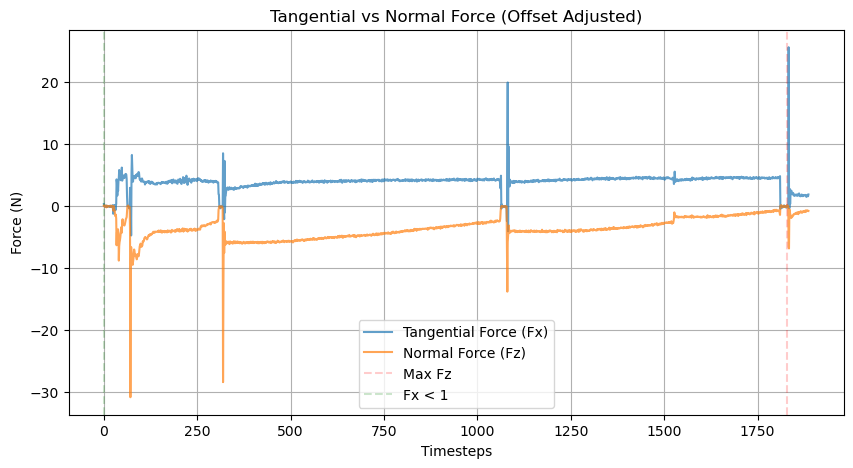

In [3]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_50_5N//log_202405240814.csv"
df = pd.read_csv(data)
test_1, end_1 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='beginning', offset_length=15)

<font size="6">Test 2: (worked)</font>

Length from cut_1 to avg_end: 497
Average Fx in the averaging interval [1000:1497]: 5.010102853704666
Average Fz in the averaging interval [1000:1497]: 0.7064001849639503
Maximum Fz in the plotting interval [1000:None]: 1.8462320963541667 at timestep 1466
Time step where Fx drops below 1: 1497


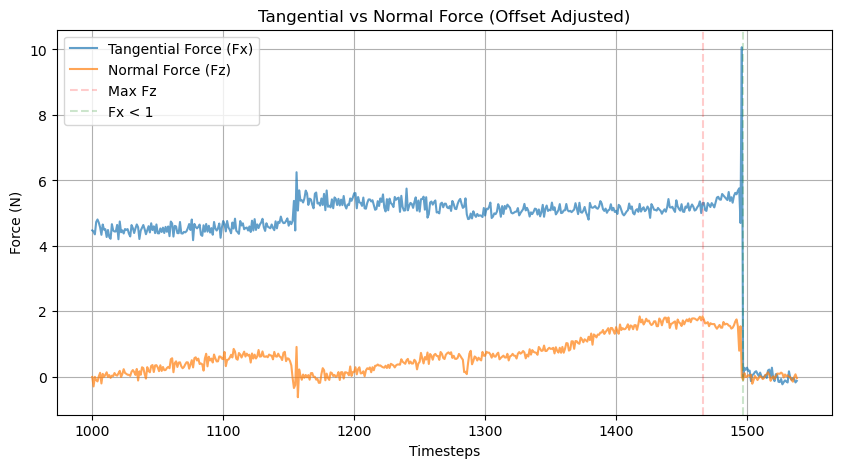

In [4]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_50_5N//log_202405240818.csv"
df = pd.read_csv(data)
test_2, end_2 = plot_forces(df, cut_1=1000, cut_2=None, avg_end=1497, offset_position='beginning', offset_length=15)

<font size="6">Test 3: (worked)</font>

Length from cut_1 to avg_end: 1526
Average Fx in the averaging interval [180:1706]: 6.092637214612732
Average Fz in the averaging interval [180:1706]: 2.758684870768656
Maximum Fz in the plotting interval [180:None]: 6.3870849609375 at timestep 1684
Time step where Fx drops below 1: 1706


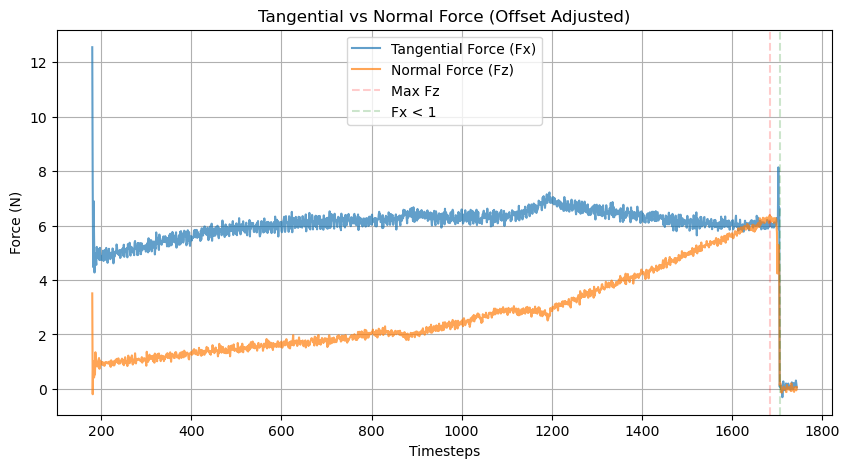

In [5]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_50_5N//log_202405240820.csv"
df = pd.read_csv(data)
test_3, end_3 = plot_forces(df, cut_1=180, cut_2=None, avg_end=1706, offset_position='beginning', offset_length=15)

<font size="6">Test 4: (worked)</font>

Length from cut_1 to avg_end: 610
Average Fx in the averaging interval [945:1555]: 3.6448863936252285
Average Fz in the averaging interval [945:1555]: 1.2532735355564806
Maximum Fz in the plotting interval [945:None]: 2.3198150634765624 at timestep 1460
Time step where Fx drops below 1: 1555


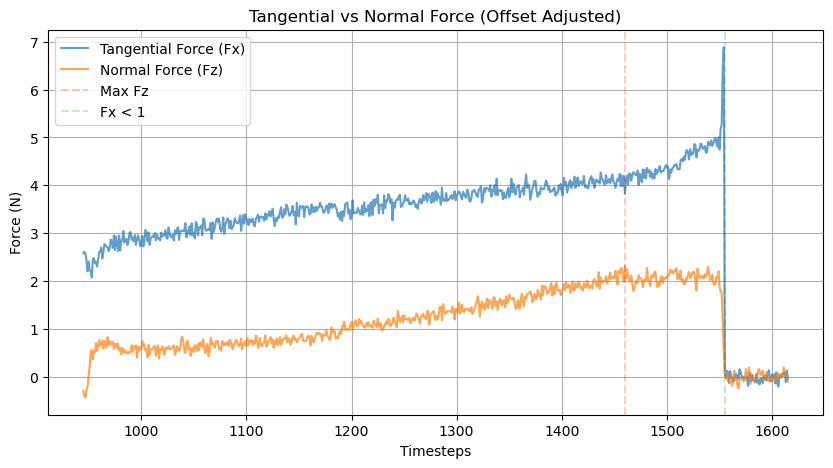

In [6]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_50_5N//log_202405240821.csv"
df = pd.read_csv(data)
test_4, end_4 = plot_forces(df, cut_1=945, cut_2=None, avg_end=1555, offset_position='end', offset_length=20)

<font size="6">Test 5: (failed)</font>

Average Fx in the averaging interval [None:None]: 2.125659427737112
Average Fz in the averaging interval [None:None]: -0.6032103112861935
Maximum Fz in the plotting interval [None:None]: 0.8244344075520833 at timestep 325
Time step where Fx drops below 1: 0


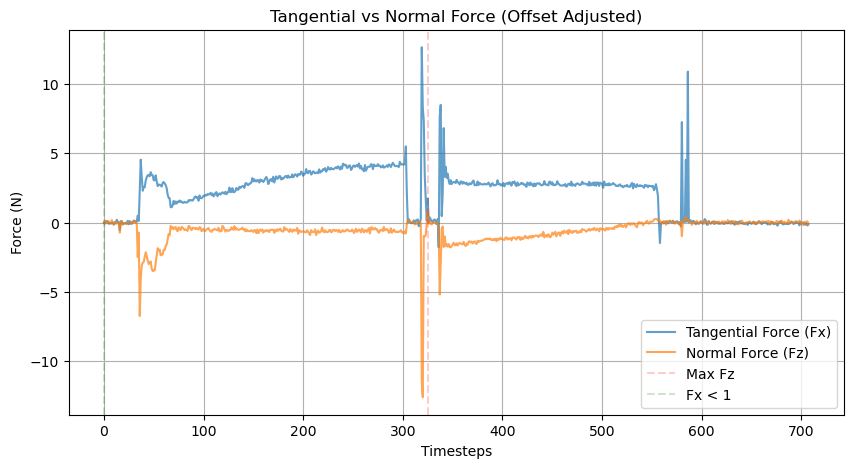

In [7]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_50_5N//log_202405240823.csv"
df = pd.read_csv(data)
test_5, end_5 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='beginning', offset_length=15)

<font size="6">Test 6: (failed)</font>

Average Fx in the averaging interval [None:450]: 4.088312427202861
Average Fz in the averaging interval [None:450]: -0.72997314453125
Maximum Fz in the plotting interval [None:450]: 0.16715087890625002 at timestep 2
Time step where Fx drops below 1: 0


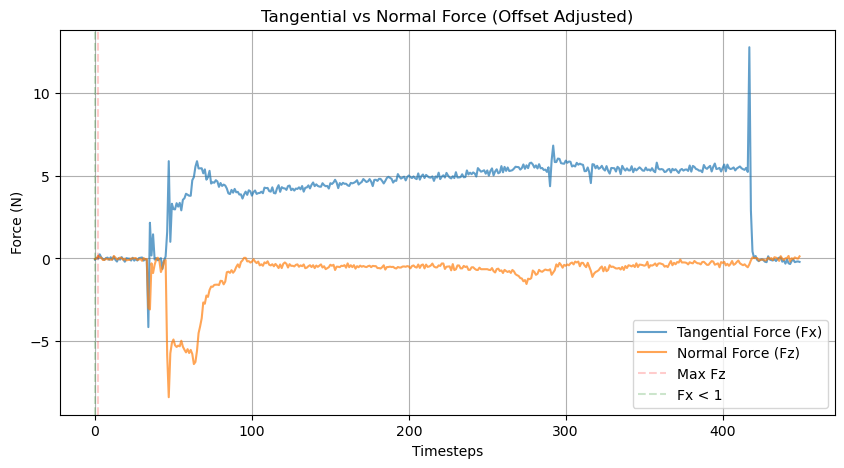

In [8]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_50_5N//log_202405240824.csv"
df = pd.read_csv(data)
test_6, end_6 = plot_forces(df, cut_1=None, cut_2=450, avg_end=None, offset_position='beginning', offset_length=15)

<font size="6">Test 7a: (worked)</font>

Length from cut_1 to avg_end: 228
Average Fx in the averaging interval [112:340]: 3.1362866987261855
Average Fz in the averaging interval [112:340]: 0.21139531721148574
Maximum Fz in the plotting interval [112:355]: 0.708642578125 at timestep 302
Time step where Fx drops below 1.5: 340


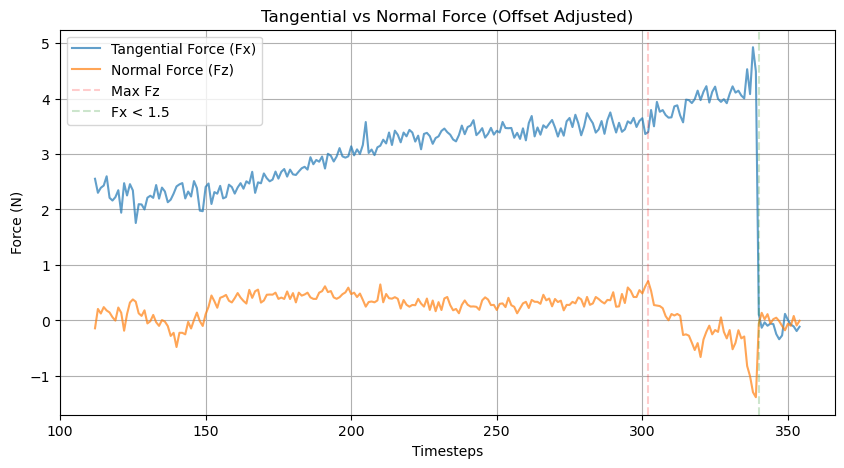

In [9]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_50_5N//log_202405240825.csv"
df = pd.read_csv(data)
test_7a, end_7a = plot_forces(df, cut_1=112, cut_2=355, avg_end=340, offset_position='end', offset_length=20, fx_threshold=1.5)

<font size="6">Test 7b: (worked)</font>

Length from cut_1 to avg_end: 264
Average Fx in the averaging interval [780:1044]: 2.7156345712416097
Average Fz in the averaging interval [780:1044]: 0.3610554550633286
Maximum Fz in the plotting interval [780:1100]: 0.899072265625 at timestep 1029
Time step where Fx drops below 1: 1044


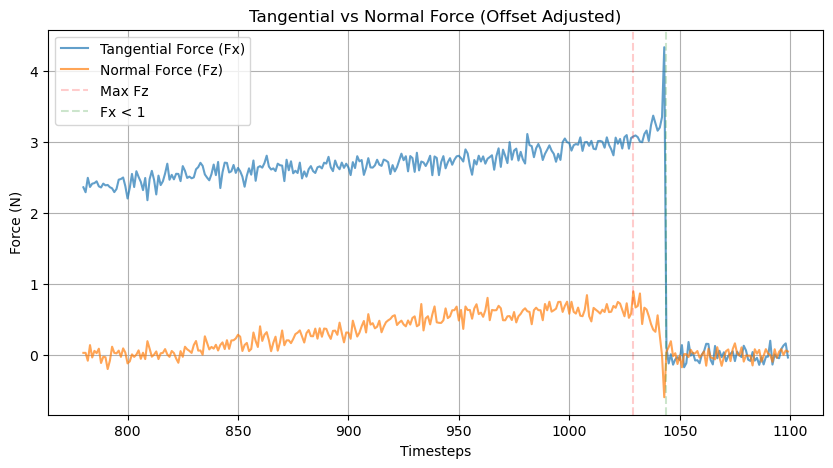

In [10]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_50_5N//log_202405240825.csv"
df = pd.read_csv(data)
test_7b, end_7b = plot_forces(df, cut_1=780, cut_2=1100, avg_end=1044, offset_position='end', offset_length=20)

<font size="6">Test 8: (worked)</font>

Length from cut_1 to avg_end: 644
Average Fx in the averaging interval [750:1394]: 5.526629624307526
Average Fz in the averaging interval [750:1394]: 1.6576045255483307
Maximum Fz in the plotting interval [750:None]: 3.5858306884765625 at timestep 1366
Time step where Fx drops below 1: 1394


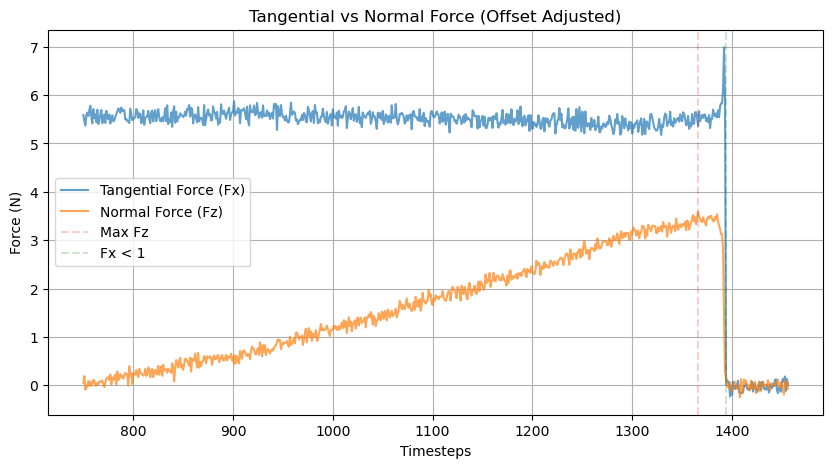

In [11]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_50_5N//log_202405240826.csv"
df = pd.read_csv(data)
test_8, end_8 = plot_forces(df, cut_1=750, cut_2=None, avg_end=1394, offset_position='end', offset_length=20)

<font size="6">Test 9a: (worked)</font>

Length from cut_1 to avg_end: 539
Average Fx in the averaging interval [233:772]: 5.448622417096083
Average Fz in the averaging interval [233:772]: 1.5999715490111175
Maximum Fz in the plotting interval [233:800]: 2.7439971923828126 at timestep 752
Time step where Fx drops below 1: 772


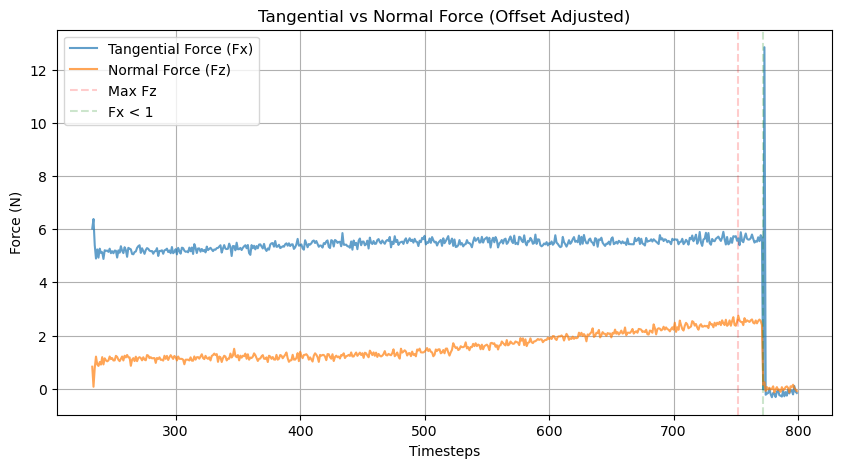

In [12]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_50_5N//log_202405240828.csv"
df = pd.read_csv(data)
test_9a, end_9a = plot_forces(df, cut_1=233, cut_2=800, avg_end=772, offset_position='end', offset_length=20)

<font size="6">Test 9b: (worked)</font>

Length from cut_1 to avg_end: 410
Average Fx in the averaging interval [840:1250]: 3.6058725851338083
Average Fz in the averaging interval [840:1250]: 1.3202577916587273
Maximum Fz in the plotting interval [840:None]: 1.6850372314453126 at timestep 1165
Time step where Fx drops below 1: 1250


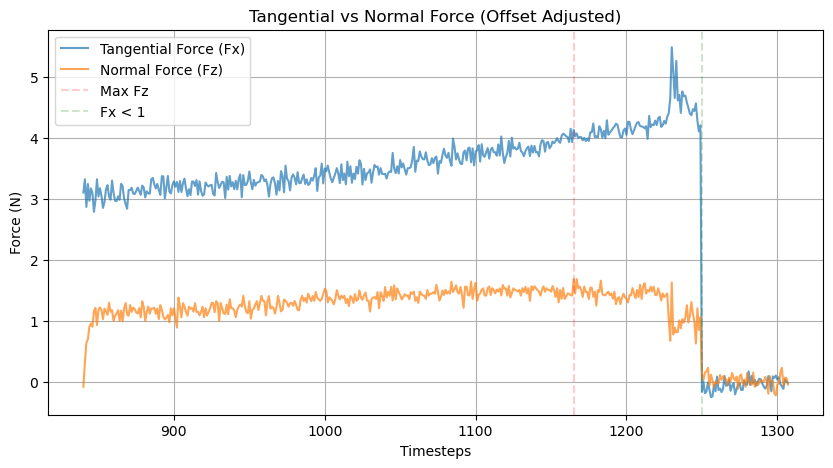

In [13]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_50_5N//log_202405240828.csv"
df = pd.read_csv(data)
test_9b, end_9b = plot_forces(df, cut_1=840, cut_2=None, avg_end=1250, offset_position='end', offset_length=20)

<font size="6">Test 10: (worked)</font>

Length from cut_1 to avg_end: 756
Average Fx in the averaging interval [590:1346]: 5.276540943932911
Average Fz in the averaging interval [590:1346]: 1.543983499839823
Maximum Fz in the plotting interval [590:None]: 3.099141438802083 at timestep 1309
Time step where Fx drops below 1: 1347


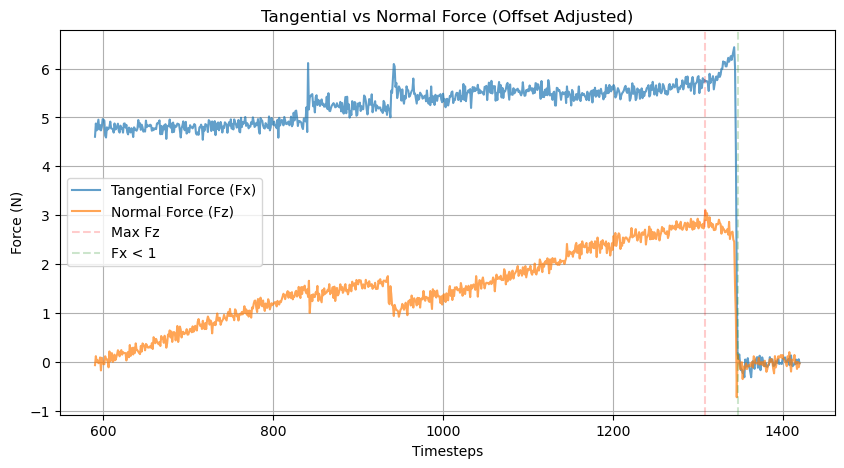

In [14]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_50_5N//log_202405240829.csv"
df = pd.read_csv(data)
test_10, end_10 = plot_forces(df, cut_1=590, cut_2=None, avg_end=1346, offset_position='end', offset_length=15)

In [15]:
def plot_multiple_tests(tests, ends):
    # Find the maximum length among all datasets
    max_length = max([end for end in ends if end is not None])
    
    plt.figure(figsize=(15, 7))
    
    for i, (test, end) in enumerate(zip(tests, ends)):
        if end is not None:
            fz_series = test['Fz']
            fz_series_cut = fz_series[:end]
            if len(fz_series_cut) < max_length:
                padded_fz = np.pad(fz_series_cut.values, (0, max_length - len(fz_series_cut)), 'constant', constant_values=np.nan)
            else:
                padded_fz = fz_series_cut.values
            plt.plot(padded_fz, label=f'Dataset {i+1} Fz', alpha=0.6)
        
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Normal Force (Fz) (N)')
    plt.legend()
    plt.title('Normal Force (Fz) of Multiple Datasets')
    plt.grid()
    plt.show()

In [50]:
def calculate_statistics(tests, ends):
    max_fz_values = []
    avg_fz_values = []
    avg_fx_values = []
    
    for test, end in zip(tests, ends):
        if end is not None:
            fz_series = test['Fz']
            fx_series = test['Fx']
            fz_series_cut = fz_series[:end]
            fx_series_cut = fx_series[:end]
            max_fz_values.append(fz_series_cut.max())
            avg_fz_values.append(fz_series_cut.mean())
            avg_fx_values.append(fx_series_cut.mean())
    
    average_max_fz = np.mean(max_fz_values)
    std_max_fz = np.std(max_fz_values)
    
    average_avg_fz = np.mean(avg_fz_values)
    std_avg_fz = np.std(avg_fz_values)
    
    average_avg_fx = np.mean(avg_fx_values)
    std_avg_fx = np.std(avg_fx_values)
    
    print(f"Average of maximum Fz forces: {average_max_fz}")
    print(f"Standard deviation of maximum Fz forces: {std_max_fz}")
    print(f"Average of average Fz forces: {average_avg_fz}")
    print(f"Standard deviation of average Fz forces: {std_avg_fz}")
    print(f"Average of average Fx forces: {average_avg_fx}")
    print(f"Standard deviation of average Fx forces: {std_avg_fx}")
    
    # Create a dictionary to store the statistics
    statistics_dict = {
        'Statistic': ['Average Max Fz', 'Std Max Fz', 'Average Avg Fz', 'Std Avg Fz', 'Average Avg Fx', 'Std Avg Fx'],
        'Value': [average_max_fz, std_max_fz, average_avg_fz, std_avg_fz, average_avg_fx, std_avg_fx]
    }
    
    # Convert the dictionary to a DataFrame
    statistics_df = pd.DataFrame(statistics_dict)
    
    # Save the statistics to a CSV file
    statistics_df.to_csv("../raw_data/Gripper Test Microspines Angles//50//Asphalt_50_stats.csv", index=False)

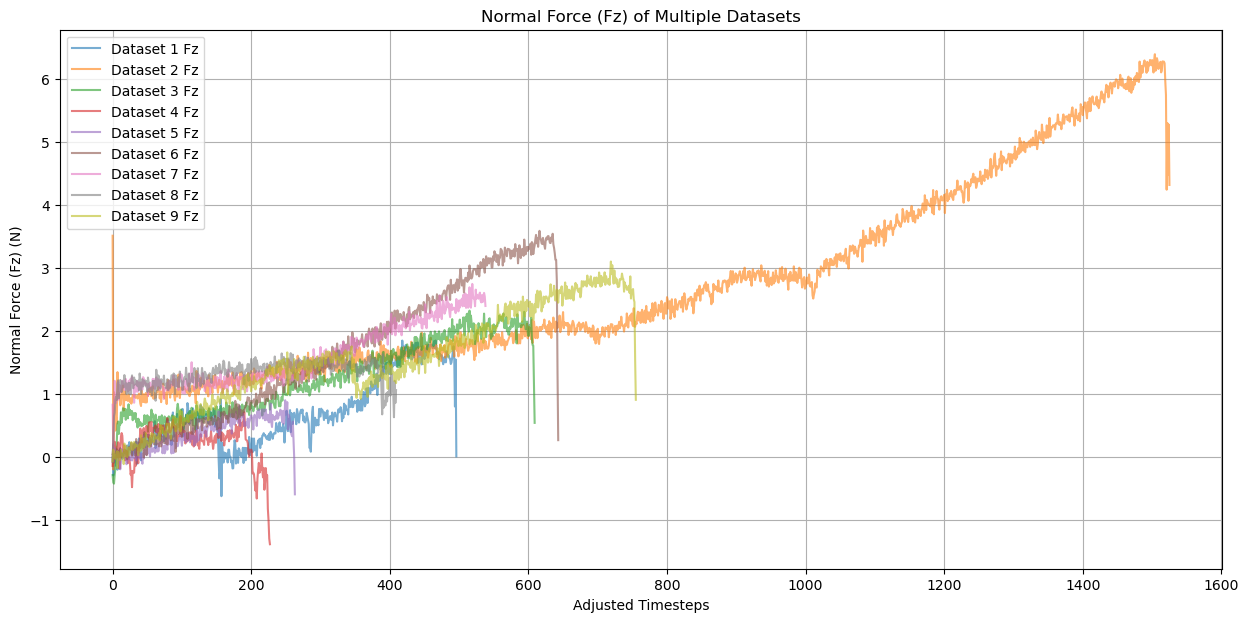

Average of maximum Fz forces: 2.5860948350694444
Standard deviation of maximum Fz forces: 1.6171382956887916
Average of average Fz forces: 1.2680696366246553
Standard deviation of average Fz forces: 0.7316350782272409
Average of average Fx forces: 4.49524592248675
Standard deviation of average Fx forces: 1.1512177410618085


In [51]:
tests = [test_2, test_3, test_4, test_7a, test_7b, test_8, test_9a, test_9b, test_10]
ends = [end_2, end_3, end_4, end_7a, end_7b, end_8, end_9a, end_9b, end_10]
plot_multiple_tests(tests, ends)
calculate_statistics(tests, ends)

In [52]:
def save_tests_to_csv_cut(tests, ends, file_prefix="../raw_data/Gripper Test Microspines Angles//50//Asphalt_50"):
    # Save each test dataset to a separate CSV file, cutting at the end point
    for i, (test, end) in enumerate(zip(tests, ends)):
        test_cut = test.iloc[:end] if end is not None else test  # Cut the test data at the end point
        test_cut.to_csv(f'{file_prefix}_{i+1}.csv', index=False)

save_tests_to_csv_cut(tests, ends)

In [41]:
from scipy.signal import savgol_filter

In [46]:
def plot_multiple_tests_with_confidence_interval(tests, ends):
    # Determine the second largest end time
    valid_ends = sorted([end for end in ends if end is not None], reverse=True)
    if len(valid_ends) < 2:
        raise ValueError("Not enough datasets with valid end times to determine the second largest timestep.")
    second_largest_end = valid_ends[1]
    
    # Initialize a list to store all valid Fz values up to their respective end times
    all_fz_list = []

    for test, end in zip(tests, ends):
        if end is not None:
            # Use min(end, second_largest_end) to ensure we only plot up to the second largest end time
            fz_series = test['Fz']
            fz_series_cut = fz_series[:min(end, second_largest_end)]
            all_fz_list.append(fz_series_cut.values)

    # Determine the maximum length among the valid Fz series up to the second largest end time
    max_length = second_largest_end
    
    # Initialize an array to store all Fz values up to the second largest end time, padded with NaN
    all_fz = np.full((len(all_fz_list), max_length), np.nan)
    
    for i, fz_series in enumerate(all_fz_list):
        all_fz[i, :len(fz_series)] = fz_series

    # Calculate mean and standard deviation at each time step
    mean_fz = np.nanmean(all_fz, axis=0)
    std_fz = np.nanstd(all_fz, axis=0)
    
    # Apply Savitzky-Golay filter to smooth out the mean Fz
    mean_fz_smooth = savgol_filter(mean_fz, window_length=51, polyorder=3)
    
    # Calculate the confidence interval
    confidence_level = 0.95
    z_score = 1.96  # Approximate value for 95% confidence
    ci_upper = mean_fz_smooth + z_score * std_fz
    ci_lower = mean_fz_smooth - z_score * std_fz
    
    plt.figure(figsize=(15, 7))
    
    # Plot the original tests
    for i, (test, end) in enumerate(zip(tests, ends)):
        if end is not None:
            fz_series = test['Fz']
            fz_series_cut = fz_series[:min(end, second_largest_end)]
            plt.plot(fz_series_cut.values, label=f'Dataset {i+1} Fz', alpha=0.3)
    
    # Plot the filtered tests
    for fz_series in all_fz_list:
        fz_series_smooth = savgol_filter(fz_series, window_length=51, polyorder=3)
        plt.plot(fz_series_smooth, color='orange', alpha=0.5)
    
    # Plot the mean Fz and confidence interval
    plt.plot(mean_fz_smooth, label='Mean Fz', color='black')
    plt.fill_between(range(max_length), ci_lower, ci_upper, color='gray', alpha=0.2, label='95% Confidence Interval')
    
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Normal Force (Fz) (N)')
    plt.legend()
    plt.title('Original and Filtered Normal Force (Fz) with Confidence Interval (Savitzky-Golay Filter)')
    plt.grid()
    plt.show()

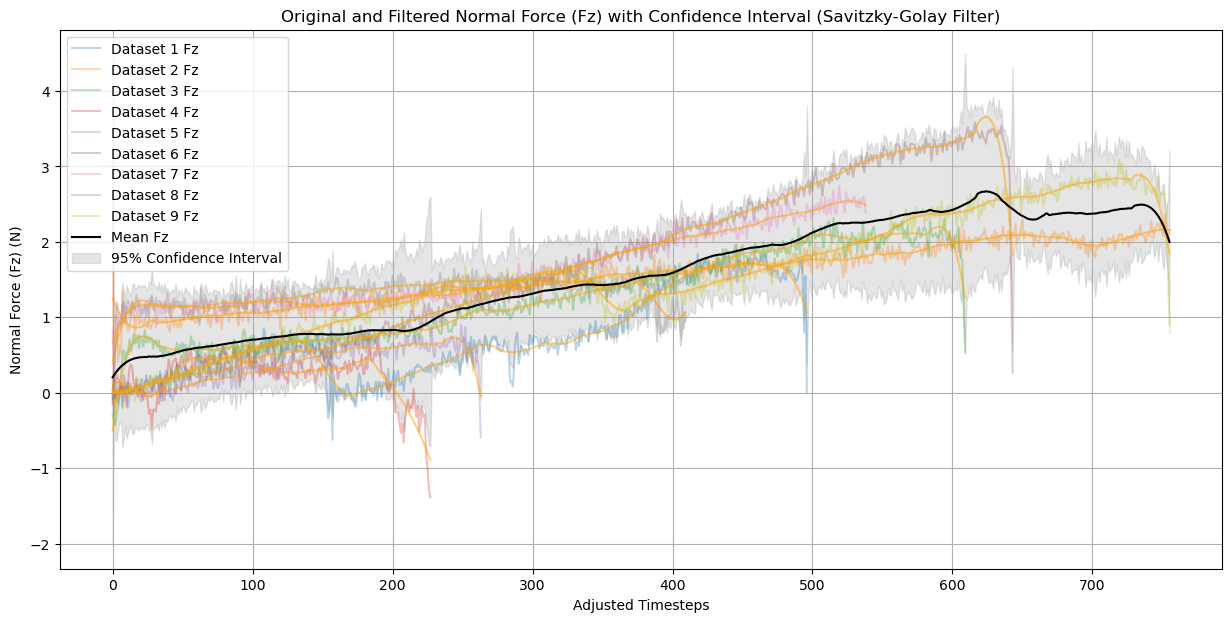

In [47]:
plot_multiple_tests_with_confidence_interval(tests, ends)

In [48]:
def plot_multiple_tests_with_confidence_interval(tests, ends):
    # Determine the second largest end time
    valid_ends = sorted([end for end in ends if end is not None], reverse=True)
    if len(valid_ends) < 2:
        raise ValueError("Not enough datasets with valid end times to determine the second largest timestep.")
    second_largest_end = valid_ends[1]
    
    # Initialize a list to store all valid Fz values up to their respective end times
    all_fz_list = []

    for test, end in zip(tests, ends):
        if end is not None:
            # Use min(end, second_largest_end) to ensure we only plot up to the second largest end time
            fz_series = test['Fz']
            fz_series_cut = fz_series[:min(end, second_largest_end)]
            fz_series_smooth = savgol_filter(fz_series_cut.values, window_length=51, polyorder=3)
            all_fz_list.append(fz_series_smooth)

    # Determine the maximum length among the valid Fz series up to the second largest end time
    max_length = second_largest_end
    
    # Initialize an array to store all Fz values up to the second largest end time, padded with NaN
    all_fz = np.full((len(all_fz_list), max_length), np.nan)
    
    for i, fz_series_smooth in enumerate(all_fz_list):
        all_fz[i, :len(fz_series_smooth)] = fz_series_smooth

    # Calculate mean and standard deviation at each time step using filtered test data
    mean_fz = np.nanmean(all_fz, axis=0)
    std_fz = np.nanstd(all_fz, axis=0)
    
    # Apply Savitzky-Golay filter to smooth out the mean Fz
    mean_fz_smooth = savgol_filter(mean_fz, window_length=51, polyorder=3)
    
    # Calculate the confidence interval using filtered test data
    confidence_level = 0.95
    z_score = 1.96  # Approximate value for 95% confidence
    ci_upper = mean_fz_smooth + z_score * std_fz
    ci_lower = mean_fz_smooth - z_score * std_fz
    
    plt.figure(figsize=(15, 7))
    
    # Plot the original tests
    for i, (test, end) in enumerate(zip(tests, ends)):
        if end is not None:
            fz_series = test['Fz']
            fz_series_cut = fz_series[:min(end, second_largest_end)]
            plt.plot(fz_series_cut.values, label=f'Dataset {i+1} Fz', alpha=0.3)
    
    # Plot the filtered tests
    for fz_series_smooth in all_fz_list:
        plt.plot(fz_series_smooth, color='orange', alpha=0.5)
    
    # Plot the mean Fz and confidence interval
    plt.plot(mean_fz_smooth, label='Mean Fz', color='black')
    plt.fill_between(range(max_length), ci_lower, ci_upper, color='gray', alpha=0.2, label='95% Confidence Interval')
    
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Normal Force (Fz) (N)')
    plt.legend()
    plt.title('Original and Filtered Normal Force (Fz) with Confidence Interval (Savitzky-Golay Filter)')
    plt.grid()
    plt.show()

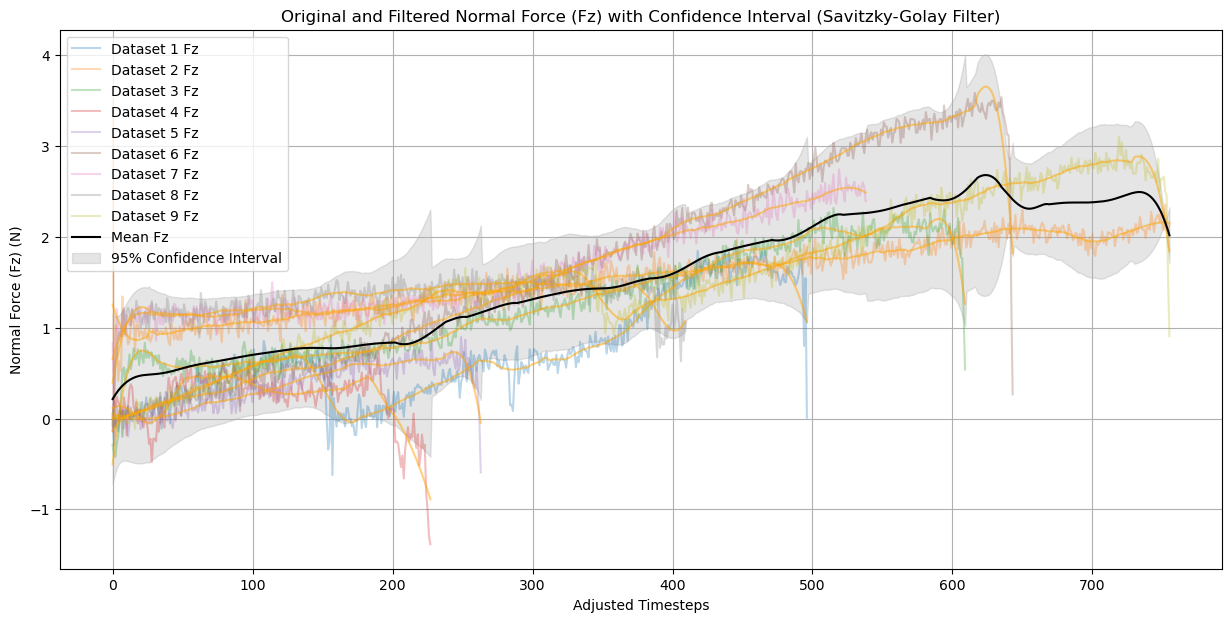

In [49]:
plot_multiple_tests_with_confidence_interval(tests, ends)